## 1. Project overview

# Dataset stats

- 25%         5.600000   54201.500000
- 50%        22.000000   84692.000000
- 75%        77.165000  139320.500000
- max     25691.160000  172792.000000

# Class Distribution plot
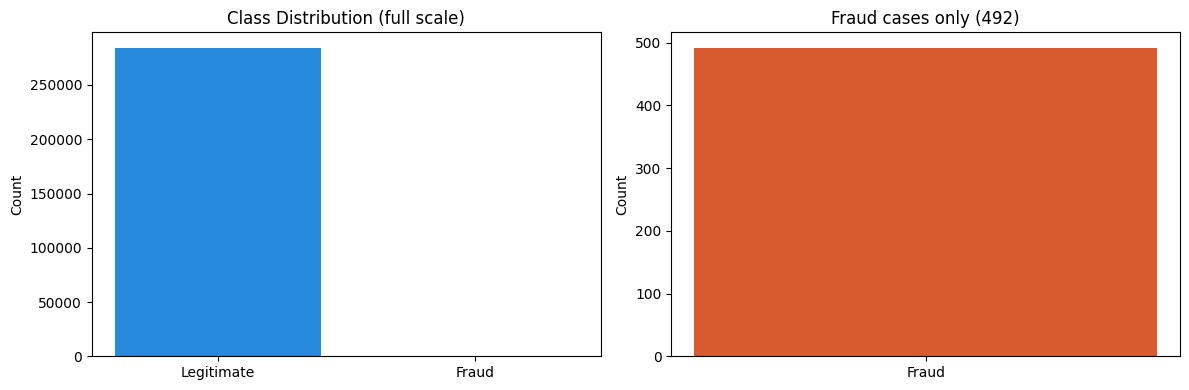

# Key challenge: 1:577 imbalance

----------------------------------------------------------------------------

## 2. Feature engineering summary 

# Feature importance bar chart (XGBoost)
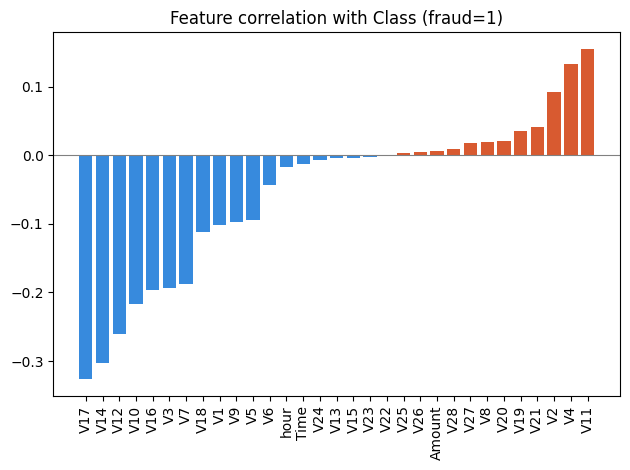

# Table 34 features
1. PCA:        V1–V28 (28 features)
2. Engineered : 
- Amount_log: Log of 'Amount' for better visualization
- hour: Transaction per hour
- day: Transaction per day
- is_night: Transaction at night
- is_round_amount: Rounded 'Amount'
- is_micro: Small Transactions

-----------------------------------------------------------------------------

## 3. Model comparison

In [5]:
# Leaderboard table (all 4 models)

'''
 === MODEL LEADERBOARD ===
                     auprc      f1  train_S
XGBoost             0.8802  0.8454      7.6
RandomForest        0.8438  0.7059     38.4
LogisticRegression  0.7181  0.1185      1.7
LightGBM            0.0565  0.0893      1.2

'''

'\n === MODEL LEADERBOARD ===\n                     auprc      f1  train_S\nXGBoost             0.8802  0.8454      7.6\nRandomForest        0.8438  0.7059     38.4\nLogisticRegression  0.7181  0.1185      1.7\nLightGBM            0.0565  0.0893      1.2\n\n'

- AUPRC + F1 bar charts side by side
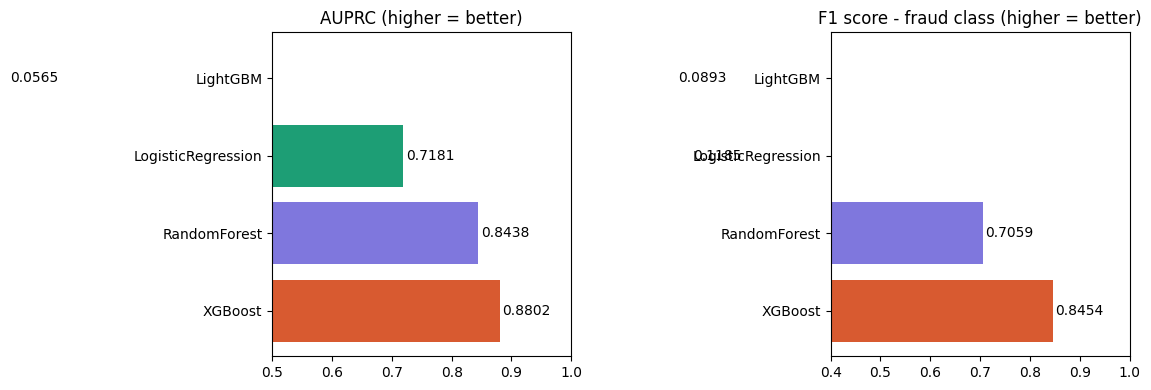

------------------------------------------------------------------------------------

## 4. Best model deep-dive (XGBoost)

# Precision-Recall & ROC curve
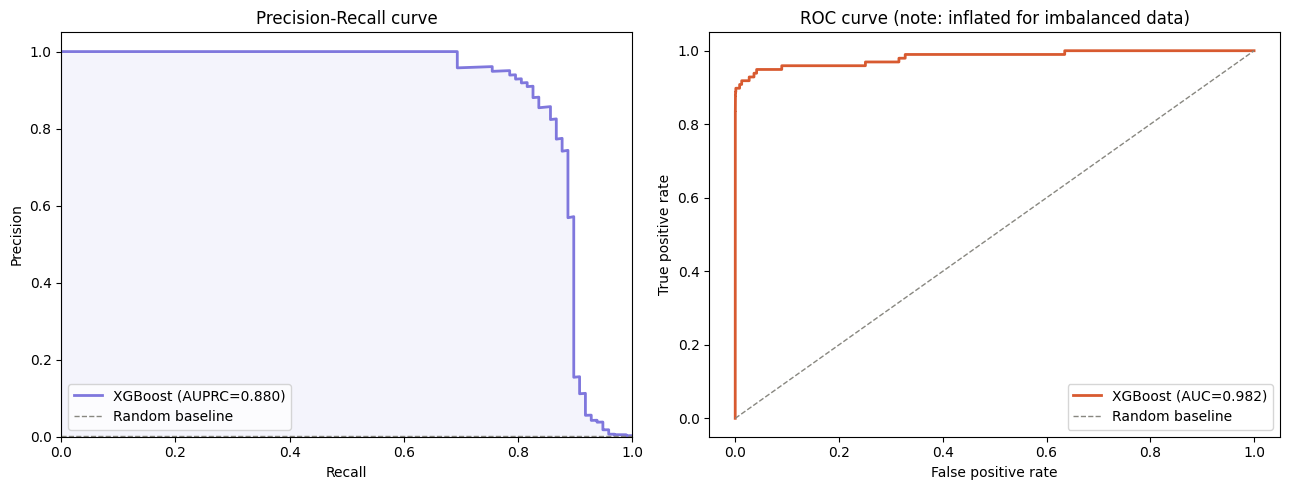

# Threshold sweep plot
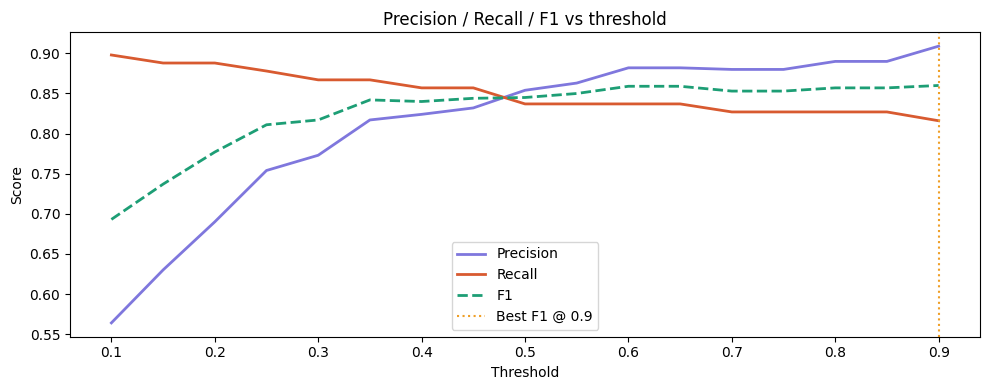

# Cost optimisation curve
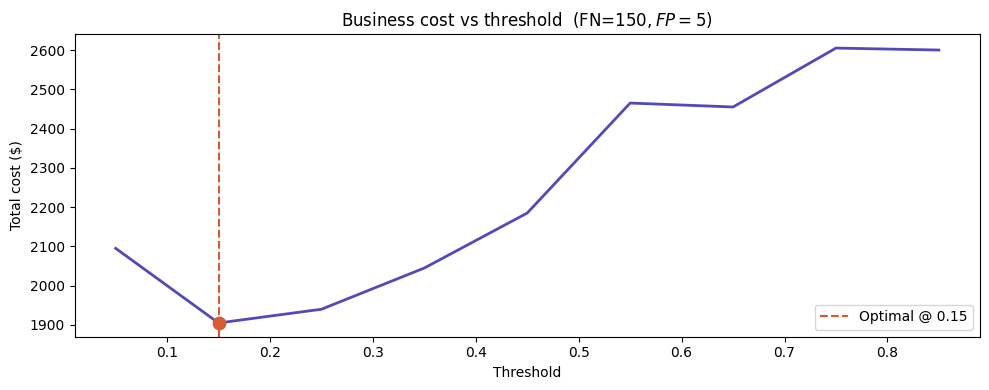

-----------------------------------------------------------------------------------------------

## 5. Final confusion matrix

# At cost-optimal threshold
- Cost-optimal threshold : 0.15

# Business cost breakdown
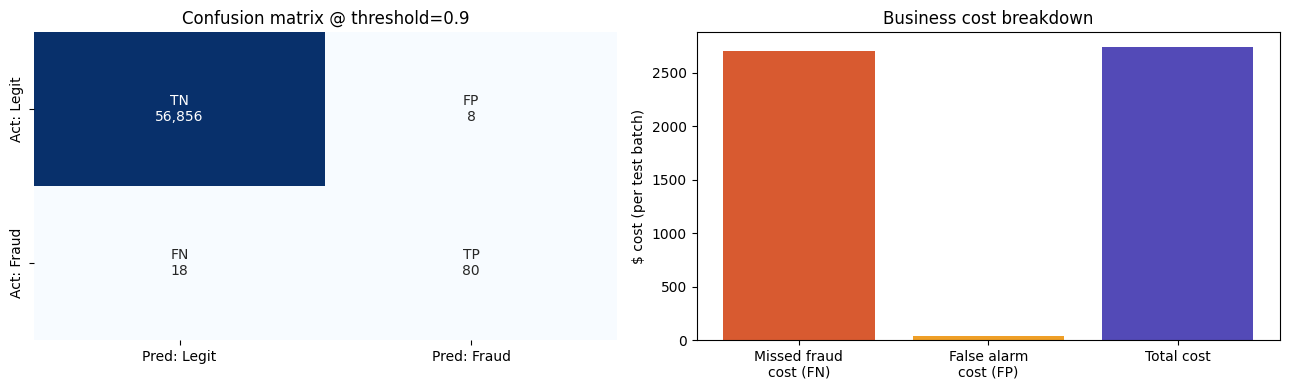

----------------------------------------------------------------------------------------------

## 6. API demo

In [2]:
import requests

FRAUD_CASE = {
    "V1":-3.04,"V2":-3.16,"V3":1.09,"V4":0.99,
    "V5":-0.49,"V6":0.59,"V7":-0.61,"V8":0.28,
    "V9":-0.45,"V10":-0.43,"V11":1.18,"V12":-1.42,
    "V13":-0.44,"V14":-2.60,"V15":0.49,"V16":-1.21,
    "V17":-2.61,"V18":-0.98,"V19":0.44,"V20":0.07,
    "V21":0.28,"V22":-0.15,"V23":-0.07,"V24":0.41,
    "V25":0.61,"V26":0.17,"V27":0.30,"V28":0.10,
    "Amount":1.00, "Time":7200
}
r = requests.post("http://localhost:8000/predict", json=FRAUD_CASE)
print("Fraud case:", r.json())

Fraud case: {'fraud_probability': 0.0114, 'flagged': False, 'risk_tier': 'low', 'threshold_used': 0.15}
